# Optimal coil arrangement for stable, open-loop hover

**Question.** With the rotor's currents frozen, what coil layout makes the spinning
magnetic field passively hold the rotor near the array axis?

Two mechanisms answer a sideways displacement $x$ off the axis, and they oppose:

| mechanism | expression | effect | sign |
|---|---|---|---|
| **restoring thrust** | $C_{tilt} = L\,G_n$,&nbsp; $L = m g (f/f_h)^2$,&nbsp; $G_n=\partial n_x/\partial r_x$ | lift points along the spin axis; if the *field rotation axis* $\hat n$ tips **inward** off-axis this pulls the rotor home | inward concavity ⇒ $C_{tilt}<0$ |
| **Earnshaw expulsion** | $C_{grad} = \partial F_x/\partial r_x$ | the lateral magnetic gradient force, forced positive by $\nabla\!\cdot\!\mathbf F=0$ wherever the axial trap $k_z<0$ | $C_{grad}>0$ |

The user's target is exactly this: **maximise the region where the rotation axis is
concave (points inward) and the restoring thrust beats the outward gradient**, while
also **maximising the magnetic flux (RMS $|B|$) inside that region**.

**Everything below is the project's own physics**, imported unchanged from
`ESP32_PMW/ai/design/` — a verified port of
`coil_modelling/matlab_refs/MultiCoilBeamformingGUI_quickGeom_rigidTilt_coil22mm.m`.
The notebook adds the *arrangement search* and the *visualisation*, and re-derives
nothing. A vectorised batch evaluator is checked against `spatial_model.field_at` to
machine precision in §2.

### Reading order
§1 setup · §2 model + verification · §3 arrangement families + coil table ·
§4 field-visualisation engine · §5 stability region + flux · §6 optimisation ·
§7 optimal design · §8 SE(3) error analysis · §9 summary.


In [ ]:
import os
import sys
import math
import time
from pathlib import Path
from dataclasses import replace

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.patches import Circle
from matplotlib.colors import TwoSlopeNorm
from scipy.optimize import brentq, differential_evolution, minimize

np.set_printoptions(precision=4, suppress=True)


def _find_repo_root():
    """Walk up from the CWD (and the script dir) to the repo that owns ESP32_PMW."""
    cands = [Path(os.getcwd()).resolve(), Path(__file__).resolve().parent] if "__file__" in globals() else [Path(os.getcwd()).resolve()]
    for start in list(cands):
        for p in [start, *start.parents]:
            if (p / "ESP32_PMW" / "ai" / "design" / "spatial_model.py").exists():
                return p
    raise RuntimeError("could not locate the repository root (ESP32_PMW/ai/design)")


ROOT = _find_repo_root()
sys.path.insert(0, str(ROOT / "ESP32_PMW"))

from ai.design import spatial_model as sm          # noqa: E402
from ai.design import open_loop_sweep as ols       # noqa: E402
from ai.design import coil_geometry as cg          # noqa: E402
from ai.design import stability_cert as sc         # noqa: E402

print("repository root :", ROOT)
print("spatial_model   :", Path(sm.__file__).relative_to(ROOT))
print("open_loop_sweep :", Path(ols.__file__).relative_to(ROOT))
print("numpy           :", np.__version__)
print("scipy           :", __import__("scipy").__version__)
print("matplotlib      :", matplotlib.__version__)


repository root : /Users/meli/Desktop/Kevin/UCB/FlyingRobotsLinLiweiLab
spatial_model   : ESP32_PMW/ai/design/spatial_model.py
open_loop_sweep : ESP32_PMW/ai/design/open_loop_sweep.py
numpy           : 2.5.3
scipy           : 1.18.1
matplotlib      : 3.11.2


## 1. Physical constants and the drive model

All in SI, all from the same source the flight stack uses:

* rotor (`robot_params`): CAD body + two N52 magnets, $m_{dip}$ from $B_r/\mu_0\cdot V$,
  inertias by the parallel-axis theorem.
* coils: loop radius $R_c=10.5$ mm, 650 turns, four drive phases
  $0^\circ,270^\circ,180^\circ,90^\circ$ around the ring — the progression that makes the
  field rotate (MATLAB `defaultCoils`).
* drive: $I_{amp}=1.25$ A, $f_{hover}=110$ Hz, drag $\tau_{drag}=k_{drag}f^2$ with
  $k_{drag}=3\times10^{-10}$ N·m/Hz², translational damping $\beta=0.2$ s⁻¹.
* lock ceiling: $\sin\varphi \le \text{LOCK\_MAX}=0.8$ (theory §12.3).


In [ ]:
ROBOT   = sm.robot_params()
GRAV    = sm.GRAVITY
F_HOVER = 110.0          # Hz, spin frequency at which lift = weight
K_DRAG  = 3.0e-10        # N*m/Hz^2
BETA    = 0.20           # 1/s
LOCK_MAX = 0.8
AMP     = 1.25           # A per coil
COIL_R  = 0.0105         # m, loop radius
TURNS   = 650
COIL_LEN = 0.022         # m, physical axial extent of a coil body
MU0     = sm.MU0
ZHAT    = np.array([0.0, 0.0, 1.0])

# mag.py's physical clearances, reused as the arrangement constraints
R_min = 2 * COIL_R + 0.0010   # centre-to-centre min for two coils in one plane
H_min = COIL_LEN + 0.0010     # min axial separation for stacked coils
R_bore = 0.0150               # central bore: keep coils off the axis

print(f"rotor mass      {ROBOT.mass*1e3:.4f} g      weight {ROBOT.weight*1e6:.1f} uN")
print(f"rotor m_dip     {ROBOT.mdip:.6e} A*m^2")
print(f"I_spin, I_trans {ROBOT.I_spin:.4e}, {ROBOT.I_trans:.4e} kg*m^2")
print(f"coil R, turns   {COIL_R*1e3:.2f} mm, {TURNS}")
print(f"clearances      R_min {R_min*1e3:.1f} mm, H_min {H_min*1e3:.1f} mm, bore {R_bore*1e3:.1f} mm")


rotor mass      0.0836 g      weight 819.8 uN
rotor m_dip     3.625678e-03 A*m^2
I_spin, I_trans 3.3578e-09, 2.0373e-09 kg*m^2
coil R, turns   10.50 mm, 650
clearances      R_min 22.0 mm, H_min 23.0 mm, bore 15.0 mm


## 2. The model, in one place

For coils with axis $\hat n_c$ at $\mathbf p_c$ the point-dipole field per ampere is
$\mathbf b_c(\mathbf r)=\frac{\mu_0}{4\pi}\big(3(\mathbf r_c\!\cdot\!\hat n_c)\mathbf r_c/d_c^5-\hat n_c/d_c^3\big)$,
$N\pi R_c^2$ moments. With drive $I_c(t)=I_c\cos(\omega t+\psi_c)$ the sum is a pure
**first harmonic**

$$B(\mathbf r,\theta)=\mathbf u(\mathbf r)\cos\theta+\mathbf v(\mathbf r)\sin\theta,
\qquad \mathbf u=\sum_c \mathbf b_c I_c\cos\psi_c,\quad \mathbf v=-\sum_c \mathbf b_c I_c\sin\psi_c .$$

From $(\mathbf u,\mathbf v)$ the exact directed rotation axis, the polarization-ellipse
semiaxes $(a,b)$ (singular values of $[\mathbf u\ \mathbf v]$, closed form) and the lock
ratio follow:

$$\hat n_{rot}=\frac{\mathbf u\times\mathbf v}{\|\mathbf u\times\mathbf v\|},\qquad
\sin\varphi=\frac{2\tau_{drag}}{m_{dip}(a+b)},\qquad
B_{rms}=\sqrt{\tfrac12(\|\mathbf u\|^2+\|\mathbf v\|^2)} .$$

### Vectorised batch evaluator (verified)
The optimiser and every field map need thousands of evaluations, so `batch_uv` computes
`(u, v, ∂u/∂r, ∂v/∂r)` for a whole grid at once using the *same* dipole formula as
`spatial_model.coil_basis`. It is **not** a new model — the check below requires it to
reproduce `spatial_model.field_at` to the last bit.


In [ ]:
def batch_uv(coils, pts):
    """Vectorised first-harmonic (u, v) and their spatial gradients for dipole coils.

    Identical maths to ``spatial_model.coil_basis`` + ``field_at``; verified in the next cell.
    Returns u, v (P,3) and du, dv (P,3,3).
    """
    pts = np.asarray(pts, float)
    d = pts[:, None, :] - coils.pos[None, :, :]                     # (P,M,3)
    dist = np.maximum(np.linalg.norm(d, axis=2), 1e-9)              # (P,M)
    m = coils.moment[None, :, :]                                    # (1,M,3)
    md = np.einsum("pmc,pmc->pm", d, m)                             # (P,M)
    k = MU0 / (4.0 * math.pi)
    b = k * (3.0 * md[:, :, None] * d / dist[:, :, None] ** 5
             - m / dist[:, :, None] ** 3)                           # (P,M,3)
    w_u, w_v = coils.phasor_weights(None)
    u = np.einsum("m,pmc->pc", w_u, b)
    v = np.einsum("m,pmc->pc", w_v, b)
    eye = np.eye(3)[None, None, :, :]
    g = (3.0 * k / dist[:, :, None, None] ** 5) * (
        md[:, :, None, None] * eye
        + np.einsum("pmc,pmd->pmcd", d, m)
        + np.einsum("pmc,pmd->pmcd", m, d)
        - 5.0 * (md / dist ** 2)[:, :, None, None] * np.einsum("pmc,pmd->pmcd", d, d)
    )
    du = np.einsum("m,pmcd->pcd", w_u, g)
    dv = np.einsum("m,pmcd->pcd", w_v, g)
    return u, v, du, dv


def nrot_of(u, v):
    n = np.cross(u, v)
    return n / np.maximum(np.linalg.norm(n, axis=1, keepdims=True), 1e-15)


def semiaxes_of(u, v):
    uu = np.einsum("pc,pc->p", u, u)
    vv = np.einsum("pc,pc->p", v, v)
    uv = np.einsum("pc,pc->p", u, v)
    tr = uu + vv
    det = np.maximum(uu * vv - uv * uv, 0.0)
    disc = np.sqrt(np.maximum(tr * tr - 4.0 * det, 0.0))
    return (np.sqrt(np.maximum(0.5 * (tr + disc), 0.0)),
            np.sqrt(np.maximum(0.5 * (tr - disc), 0.0)))


def rms_of(u, v):
    return np.sqrt(0.5 * (np.einsum("pc,pc->p", u, u) + np.einsum("pc,pc->p", v, v)))


# --- verification against the imported reference implementation -------------------
_ref = sm.quick_coils("cross", d=0.037, tilt_deg=7.0, amp=1.25, pitch=0.021, model="dipole")
_rng = np.random.default_rng(0)
_pts = np.column_stack([_rng.uniform(-0.03, 0.03, 40), _rng.uniform(-0.03, 0.03, 40),
                        _rng.uniform(0.008, 0.040, 40)])
_U, _V, _DU, _DV = batch_uv(_ref, _pts)
_err = 0.0
for _i, _r in enumerate(_pts):
    _u, _v, _du, _dv = sm.field_at(_r, _ref, None, True)
    _err = max(_err, np.max(np.abs(_u - _U[_i])), np.max(np.abs(_v - _V[_i])),
               np.max(np.abs(_du - _DU[_i])), np.max(np.abs(_dv - _DV[_i])))
print(f"max |batch_uv - spatial_model.field_at| over 40 random points: {_err:.3e}")
assert _err < 1e-14, "batch evaluator diverged from the reference port"
print("batch evaluator verified identical to the port.")


max |batch_uv - spatial_model.field_at| over 40 random points: 0.000e+00
batch evaluator verified identical to the port.


### 2.1 Sanity check against the project's own stability screen

`open_loop_sweep.evaluate` computes $z_{eq}$, $C_{net}$, $k_z$ and $R$ on axis. The
pointwise machinery used later must reproduce those numbers exactly at the axis, or the
whole region map is untrustworthy. Below we re-implement the *axial trim* + on-axis
metrics with the batch evaluator and diff them against `ols.evaluate`.


In [ ]:
def axial_fz(coils, f, z, need):
    """On-axis axial force residual: gradient force z minus the lift deficit."""
    u, v, du, dv = batch_uv(coils, np.array([[0.0, 0.0, z]]))
    a, b = semiaxes_of(u, v)
    ratio = 2.0 * (K_DRAG * f * f) / (ROBOT.mdip * (a + b))
    if ratio[0] > 1.0:
        return math.nan
    phi = math.asin(ratio[0])
    _, mc, ms = sm.cycle_average(ZHAT, u[0], v[0], nrot_of(u, v)[0], ROBOT.mdip, phi)
    return sm.gradient_force(mc, ms, du[0], dv[0])[2] - need


def axial_trim(coils, f, z_lo=0.006, z_hi=0.050, n=150, f_hover=F_HOVER):
    """Every on-axis equilibrium and its axial stiffness ``(z, k_z)``. Matches ols.trim."""
    need = ROBOT.mass * GRAV * (1.0 - (f / f_hover) ** 2)
    zs = np.linspace(z_lo, z_hi, n)
    vals = np.array([axial_fz(coils, f, z, need) for z in zs])
    out, h = [], 1e-5
    for i in range(n - 1):
        a, b = vals[i], vals[i + 1]
        if np.isfinite(a) and np.isfinite(b) and a * b < 0.0:
            z = brentq(lambda zz: axial_fz(coils, f, zz, need), zs[i], zs[i + 1], xtol=1e-9)
            kz = (axial_fz(coils, f, z + h, need) - axial_fz(coils, f, z - h, need)) / (2 * h)
            out.append((z, kz))
    return out


_rows = []
for (d, t, fr) in [(0.037, 0.0, 110.0), (0.046, 15.0, 92.0), (0.048, 2.0, 95.0)]:
    co = sm.quick_coils("cross", d=d, tilt_deg=t, amp=1.25, pitch=0.021, model="dipole")
    row = ols.evaluate(d=d, tilt_deg=t, f=fr, model="dipole")
    ref = [(z, k) for z, k in axial_trim(co, fr) if k < 0]
    if row is None or not ref:
        continue
    z_mine, k_mine = ref[-1]
    _rows.append(dict(d_mm=d * 1e3, tilt_deg=t, f_Hz=fr,
                      z_ols_mm=row["z_eq"] * 1e3, z_mine_mm=z_mine * 1e3,
                      kz_ols=row["k_z"], kz_mine=k_mine,
                      Cn_ols=row["C_net"], R_ols=row["R"]))
print(pd.DataFrame(_rows).to_string(index=False, float_format=lambda x: f"{x: .5f}"))
print("\n> axial trim and k_z agree with open_loop_sweep.evaluate to the printed digits.")


     d_mm  tilt_deg       f_Hz  z_ols_mm  z_mine_mm   kz_ols  kz_mine   Cn_ols    R_ols
 37.00000   0.00000  110.00000  15.15633   15.15633 -0.10714 -0.10714  0.05357  0.13775
 46.00000  15.00000   92.00000  18.38721   18.38721 -0.03075 -0.03075 -0.01574  0.07327
 48.00000   2.00000   95.00000  14.54433   14.54433 -0.03207 -0.03207 -0.00606  0.09677

> axial trim and k_z agree with open_loop_sweep.evaluate to the printed digits.


## 3. Arrangement families

Baseline is the requested **4×4 grid, no modifications**: 16 coils on a square lattice of
pitch $p$, all normals $+\hat z$. The four 2×2 quadrants carry the four drive phases; the
phase is $-(\text{azimuth})$ so the field rotates (matching the MATLAB ring convention).

On top of that we build every family the task names, plus the two the theory says matter:

| family | normal rule | note |
|---|---|---|
| `baseline` | $\hat z$ | plain 4×4 grid |
| `cluster_out/in` | each quadrant tilted radially **out/in** by $\theta$ | "uniform tilt per 2×2 cluster" |
| `percoil_out/in` | each **coil** tilted along its own radius by $\theta$ | "per coil" |
| `focal` | every normal aimed at a focus $(0,0,z_f)$ | convergent variant |
| `two_ring` | inner/outer ring split in $z$; upper ring **reverse-wound** (phase $+\pi$) | theory §15.1 |

The builder returns an `spatial_model.Coils`, so the entire imported physics works on it.


In [ ]:
N = 4  # 4x4 grid


def skew(a):
    a = np.asarray(a, float)
    return np.array([[0.0, -a[2], a[1]], [a[2], 0.0, -a[0]], [-a[1], a[0], 0.0]])


def grid_xy(pitch):
    """4x4 lattice centred on the origin, in the array plane."""
    c = (np.arange(N) - (N - 1) / 2.0) * pitch
    X, Y = np.meshgrid(c, c)
    return np.column_stack([X.ravel(), Y.ravel()])


def quadrant_of(xy):
    return (xy[:, 0] > 0).astype(int) * 2 + (xy[:, 1] > 0).astype(int)


def phases_of(xy):
    """Drive phase = -azimuth of the (quadrant) centre, so the field rotates."""
    return np.degrees(-np.arctan2(xy[:, 1], xy[:, 0]))


def build_coils(xy, z, nhat, phase_deg, amp=AMP, model="dipole"):
    """Assemble an ``sm.Coils`` from centres, heights and normals."""
    xy = np.asarray(xy, float)
    z = np.broadcast_to(np.asarray(z, float), (len(xy),))
    nhat = np.asarray(nhat, float)
    nhat = nhat / np.linalg.norm(nhat, axis=1, keepdims=True)
    pos = np.column_stack([xy, z])
    moment = TURNS * math.pi * COIL_R ** 2 * nhat
    return sm.Coils(pos=pos, nhat=nhat, moment=moment,
                    amp=np.full(len(xy), float(amp)),
                    phase=np.radians(np.asarray(phase_deg, float)),
                    channel=quadrant_of(xy),
                    radius=np.full(len(xy), COIL_R),
                    turns=np.full(len(xy), float(TURNS)),
                    model=model)


def n_flat(xy):
    return np.tile([0.0, 0.0, 1.0], (len(xy), 1))


def _tilt_about(nhat, axis, ang):
    K = skew(axis)
    R = math.cos(ang) * np.eye(3) + (1 - math.cos(ang)) * np.outer(axis, axis) + math.sin(ang) * K
    return R @ nhat


def n_cluster(xy, tilt_deg):
    """Per 2x2 cluster: rotate the whole cluster's normal about its tangential axis."""
    qid = quadrant_of(xy)
    nh = np.zeros((len(xy), 3))
    a = math.radians(tilt_deg)
    for q in range(4):
        m = qid == q
        c = xy[m].mean(axis=0)
        er = c / max(np.linalg.norm(c), 1e-12)      # outward radial
        et = np.array([-er[1], er[0], 0.0])         # tangential tilt axis
        nh[m] = _tilt_about(ZHAT, et, a)            # +a = outward normal tilt
    return nh


def n_percoil(xy, tilt_deg):
    """Each coil along its own radius: n = sin(a) er + cos(a) zhat."""
    r = np.linalg.norm(xy, axis=1, keepdims=True)
    er = xy / np.maximum(r, 1e-12)
    a = math.radians(tilt_deg)
    return np.column_stack([er[:, 0] * math.sin(a), er[:, 1] * math.sin(a),
                            np.full(len(xy), math.cos(a))])


def n_focal(xy, z_coil, z_focus):
    v = np.column_stack([-xy[:, 0], -xy[:, 1], np.full(len(xy), z_focus - z_coil)])
    return v / np.linalg.norm(v, axis=1, keepdims=True)


def two_ring(xy, pitch, gap, reverse=True):
    """Split the lattice into an inner (r < pitch) and outer ring, offset in z.

    The upper ring is reverse-wound by flipping its phase by pi, which makes the two rings
    *add* instead of cancel (theory section 15.1).
    """
    r = np.linalg.norm(xy, axis=1)
    outer = r > pitch * 1.05
    z = np.where(outer, gap, 0.0)
    ph = phases_of(xy)
    if reverse:
        ph = np.where(outer, ph + 180.0, ph)
    return z, ph


def family(name, pitch, tilt_deg=0.0, z_focus=0.045, gap=0.012):
    """Return ``(xy, z, nhat, phase_deg)`` for one named arrangement family."""
    xy = grid_xy(pitch)
    if name == "baseline":
        return xy, np.zeros(len(xy)), n_flat(xy), phases_of(xy)
    if name == "cluster_out":
        return xy, np.zeros(len(xy)), n_cluster(xy, tilt_deg), phases_of(xy)
    if name == "cluster_in":
        return xy, np.zeros(len(xy)), n_cluster(xy, -tilt_deg), phases_of(xy)
    if name == "percoil_out":
        return xy, np.zeros(len(xy)), n_percoil(xy, tilt_deg), phases_of(xy)
    if name == "percoil_in":
        return xy, np.zeros(len(xy)), n_percoil(xy, -tilt_deg), phases_of(xy)
    if name == "focal":
        return xy, np.zeros(len(xy)), n_focal(xy, 0.0, z_focus), phases_of(xy)
    if name == "two_ring":
        z, ph = two_ring(xy, pitch, gap)
        return xy, z, n_flat(xy), ph
    raise ValueError(name)


FAMILIES = ["baseline", "cluster_out", "cluster_in", "percoil_out", "percoil_in", "focal", "two_ring"]
print("families:", FAMILIES)


families: ['baseline', 'cluster_out', 'cluster_in', 'percoil_out', 'percoil_in', 'focal', 'two_ring']


### 3.1 Coil table

The requested table of **positions and orientations**. `tilt_from_z` is
$\arccos(n_z)$ in degrees; `cluster` is the 2×2 quadrant index (0..3).


In [ ]:
def coil_table(coils, label=""):
    n = np.asarray(coils.nhat, float)
    n = n / np.linalg.norm(n, axis=1, keepdims=True)
    return pd.DataFrame({
        "coil": np.arange(len(n)),
        "x_mm": coils.pos[:, 0] * 1e3,
        "y_mm": coils.pos[:, 1] * 1e3,
        "z_mm": coils.pos[:, 2] * 1e3,
        "nx": n[:, 0], "ny": n[:, 1], "nz": n[:, 2],
        "tilt_from_z_deg": np.degrees(np.arccos(np.clip(n[:, 2], -1, 1))),
        "phase_deg": np.degrees(coils.phase) % 360.0,
        "cluster": coils.channel,
        "family": label,
    })


PITCH0 = 0.024
xy, z0, nh, ph = family("baseline", PITCH0)
base_coils = build_coils(xy, z0, nh, ph)
print("baseline 4x4 grid — coil positions and orientations")
print(coil_table(base_coils, "baseline").to_string(index=False, float_format=lambda v: f"{v: 8.4f}"))


baseline 4x4 grid — coil positions and orientations
 coil     x_mm     y_mm     z_mm       nx       ny       nz  tilt_from_z_deg  phase_deg  cluster   family
    0 -36.0000 -36.0000   0.0000   0.0000   0.0000   1.0000           0.0000   135.0000        0 baseline
    1 -12.0000 -36.0000   0.0000   0.0000   0.0000   1.0000           0.0000   108.4349        0 baseline
    2  12.0000 -36.0000   0.0000   0.0000   0.0000   1.0000           0.0000    71.5651        2 baseline
    3  36.0000 -36.0000   0.0000   0.0000   0.0000   1.0000           0.0000    45.0000        2 baseline
    4 -36.0000 -12.0000   0.0000   0.0000   0.0000   1.0000           0.0000   161.5651        0 baseline
    5 -12.0000 -12.0000   0.0000   0.0000   0.0000   1.0000           0.0000   135.0000        0 baseline
    6  12.0000 -12.0000   0.0000   0.0000   0.0000   1.0000           0.0000    45.0000        2 baseline
    7  36.0000 -12.0000   0.0000   0.0000   0.0000   1.0000           0.0000    18.4349        2 bas

## 4. Field-visualisation engine

Every field map obeys the task's rules:

* **colour = the horizontal part of the rotation axis**, from
  $\hat n_{rot}\times\hat z$: its magnitude $\sqrt{n_x^2+n_y^2}$ is the tilt of the
  spinning-field axis, and its **sign along the outward radius** distinguishes
  *inward* (blue — concave, restoring) from *outward* (red — convex, expelling);
* arrows show $\hat n_{rot}$ itself, sampled on the grid;
* thin grey contours are $B_{rms}$ (the flux the task wants maximised);
* a **thick black curve marks $C_{net}=0$** — *the locus where the lateral gradient
  force equals the restoring thrust*, the exact boundary the task asks to draw;
* the **coil arrangement is always rendered** (top-down circles + normal arrows, or a 3-D
  coil/frame view).


In [ ]:
ZHAT3 = np.array([0.0, 0.0, 1.0])


def _signed_horiz(nr, X, Y):
    """Signed horizontal tilt of the rotation axis: + outward, - inward (concave)."""
    nx, ny = nr[:, 0].reshape(X.shape), nr[:, 1].reshape(X.shape)
    r = np.hypot(X, Y)
    rhat = np.where(r > 0, r, 1.0)
    hrad = (nx * X + ny * Y) / rhat
    return np.sign(hrad) * np.hypot(nx, ny)


def draw_coils_2d(ax, coils, color_by_z=True, scale=1.0):
    """Top-down coil render: a body circle per coil plus its normal projection."""
    for c in range(len(coils.pos)):
        x, y = coils.pos[c, 0] * 1e3, coils.pos[c, 1] * 1e3
        n = coils.nhat[c]
        col = cm.viridis(np.clip(coils.pos[c, 2] / max(1e-6, np.ptp(coils.pos[:, 2]) + 1e-9), 0, 1)) \
            if color_by_z else "0.35"
        ax.add_patch(Circle((x, y), COIL_R * 1e3, facecolor=col, edgecolor="k",
                            lw=0.6, alpha=0.55, zorder=6))
        ax.quiver(x, y, n[0], n[1], color="k", width=0.006, scale=8.0 / scale,
                  zorder=7, alpha=0.9)


def field_metrics(coils, f, z_eval, ext=0.030, G=41, f_hover=F_HOVER, lock_max=LOCK_MAX, h=2e-4):
    """Every stability quantity on the plane z = z_eval, at once.

    Returns a dict with the grid, the field, and the per-point stability terms. The spin
    axis is frozen at the on-axis trim orientation ``zhat`` -- exactly the linearisation
    ``open_loop_sweep.evaluate`` uses off axis.
    """
    xs = np.linspace(-ext, ext, G)
    X, Y = np.meshgrid(xs, xs)
    base = np.column_stack([X.ravel(), Y.ravel(), np.full(X.size, z_eval)])

    def uv(pts):
        u, v, du, dv = batch_uv(coils, pts)
        nr = nrot_of(u, v)
        a, b = semiaxes_of(u, v)
        ratio = 2.0 * (K_DRAG * f * f) / (ROBOT.mdip * (a + b))
        phi = np.arcsin(np.clip(ratio, -1.0, 1.0))
        F = np.zeros_like(pts)
        for i in range(len(pts)):
            if ratio[i] <= 1.0:
                _, mc, ms = sm.cycle_average(ZHAT, u[i], v[i], nr[i], ROBOT.mdip, phi[i])
                F[i] = sm.gradient_force(mc, ms, du[i], dv[i])
        return u, v, nr, a, b, ratio, phi, F

    u, v, nr, a, b, ratio, phi, F = uv(base)
    _, _, nrp, _, _, _, _, Fxp = uv(base + [h, 0.0, 0.0])
    _, _, nrm, _, _, _, _, Fxm = uv(base - [h, 0.0, 0.0])
    _, _, _, _, _, _, _, Fzp = uv(base + [0.0, 0.0, h])
    _, _, _, _, _, _, _, Fzm = uv(base - [0.0, 0.0, h])

    G_n = (nrp[:, 0] - nrm[:, 0]) / (2 * h)
    C_grad = (Fxp[:, 0] - Fxm[:, 0]) / (2 * h)
    k_z = (Fzp[:, 2] - Fzm[:, 2]) / (2 * h)
    L = ROBOT.mass * GRAV * (f / f_hover) ** 2
    C_tilt = L * G_n
    C_net = C_tilt + C_grad
    kappa_t = 0.25 * ROBOT.mdip * (a + b) * np.cos(phi)
    omega = 2.0 * math.pi * f
    Om_align = kappa_t / (ROBOT.I_spin * omega)
    lam_grad = np.sqrt(np.maximum(C_grad, 0.0) / ROBOT.mass)
    R = np.where(C_grad > 0.0, Om_align / np.maximum(lam_grad, 1e-12), np.inf)

    hsign = (nr[:, 0] * X.ravel() + nr[:, 1] * Y.ravel())
    inward = hsign < 0.0
    geom = inward & (C_net < 0.0) & (ratio <= lock_max)
    band = geom & (R > 1.0)

    dA = (2 * ext / (G - 1)) ** 2
    rms = rms_of(u, v)
    return dict(X=X, Y=Y, ext=ext, G=G, z=z_eval, dA=dA,
                nr=nr, u=u, v=v, rms=rms, a=a, b=b, ratio=ratio, phi=phi,
                G_n=G_n, C_grad=C_grad, C_tilt=C_tilt, C_net=C_net, k_z=k_z,
                Om_align=Om_align, lam_grad=lam_grad, R=R,
                inward=inward, geom=geom, band=band,
                area=float(geom.sum() * dA),
                flux_mean=float(rms[geom].mean() if geom.any() else 0.0),
                flux_int=float(geom.sum() * dA * (rms[geom].mean() if geom.any() else 0.0)),
                maxR=float(np.max(R[np.isfinite(R)])) if np.isfinite(R).any() else math.inf)


def plot_field(ax, coils, pm, title="", show_region=True, quiver_step=3, coil_scale=1.0):
    """One field map: signed rotation-axis colour, RMS contours, C_net=0, region, coils."""
    X, Y = pm["X"] * 1e3, pm["Y"] * 1e3
    C = _signed_horiz(pm["nr"], pm["X"], pm["Y"])
    vmax = max(np.nanmax(np.abs(C)), 1e-6)
    cf = ax.contourf(X, Y, C, levels=41, cmap="RdBu_r",
                     norm=TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax))
    ax.contour(X, Y, C, levels=[0.0], colors="k", linewidths=0.6, alpha=0.5)
    rms = pm["rms"].reshape(pm["X"].shape) * 1e3
    ax.contour(X, Y, rms, levels=8, colors="0.25", linewidths=0.5, alpha=0.7)
    cn = pm["C_net"].reshape(pm["X"].shape)
    if np.nanmin(cn) < 0 < np.nanmax(cn):
        ax.contour(X, Y, cn, levels=[0.0], colors="k", linewidths=2.6)
    if show_region and pm["geom"].any():
        g = pm["geom"].reshape(pm["X"].shape).astype(float)
        # boundaries of the region
        ax.contour(X, Y, g, levels=[0.5], colors="lime", linewidths=2.2)
        ax.contourf(X, Y, g, levels=[0.5, 1.5], colors="none", hatches=["///"],
                    edgecolor="lime")
    nrm = pm["nr"].reshape(pm["X"].size, 3)
    st = quiver_step
    ax.quiver(X[::st, ::st], Y[::st, ::st], nrm[:, 0].reshape(X.shape)[::st, ::st],
              nrm[:, 1].reshape(X.shape)[::st, ::st], color="k", alpha=0.65,
              width=0.0035, scale=22.0)
    draw_coils_2d(ax, coils, scale=coil_scale)
    ax.set_aspect("equal")
    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]")
    ax.set_title(title)
    return cf


def rich_field_figure(coils, f, title):
    """A 2-panel figure: field map + a 3-D coil/frame render with the field axis."""
    tr = [(z, k) for z, k in axial_trim(coils, f) if k < 0]
    if not tr:
        print(f"[skip] no stable axial trim for '{title}'")
        return None
    z_eq, k_z = tr[-1]
    pm = field_metrics(coils, f, z_eq)
    fig = plt.figure(figsize=(15, 6))
    ax0 = fig.add_subplot(1, 2, 1)
    cf = plot_field(ax0, coils, pm, title=f"{title}\nz_eq={z_eq*1e3:.1f} mm, area={pm['area']*1e6:.0f} mm², max R={pm['maxR']:.3f}")
    fig.colorbar(cf, ax=ax0, shrink=0.85, label="rotation-axis horiz. tilt  (−inward / +outward)")
    ax1 = fig.add_subplot(1, 2, 2, projection="3d")
    render_3d(ax1, coils, pm)
    ax1.set_title("coil arrangement + field rotation axis")
    fig.tight_layout()
    plt.show()
    return pm


def render_3d(ax, coils, pm):
    """3-D coil/frame render with the field rotation axis on the plane."""
    for c in range(len(coils.pos)):
        x, y, z = coils.pos[c] * 1e3
        ax.scatter([x], [y], [z], s=42, color="tab:orange", depthshade=False)
        ax.quiver(x, y, z, coils.nhat[c, 0], coils.nhat[c, 1], coils.nhat[c, 2],
                  length=9.0, color="k", lw=0.8, arrow_length_ratio=0.35)
    st = 5
    Xg = pm["X"][::st, ::st]; Yg = pm["Y"][::st, ::st]
    nr = pm["nr"].reshape(pm["X"].size, 3)
    U = nr[:, 0].reshape(pm["X"].shape)[::st, ::st]
    V = nr[:, 1].reshape(pm["X"].shape)[::st, ::st]
    W = nr[:, 2].reshape(pm["X"].shape)[::st, ::st]
    ax.quiver(Xg * 1e3, Yg * 1e3, np.full_like(Xg, pm["z"] * 1e3),
              U, V, W, length=7.0, color="tab:red", alpha=0.7, arrow_length_ratio=0.3)
    ax.set_xlabel("x [mm]"); ax.set_ylabel("y [mm]"); ax.set_zlabel("z [mm]")
    ax.set_box_aspect((1, 1, 0.5))


print("engine ready")


engine ready


### 4.1 The baseline field

The task's headline map. The colour is the horizontal part of the spinning-field axis;
the black curve is where the restoring thrust exactly cancels the lateral gradient; the
green hatch is the region where the axis is inward-concave *and* thrust wins *and* the
rotor can still phase-lock; the circles are the 16 coils.


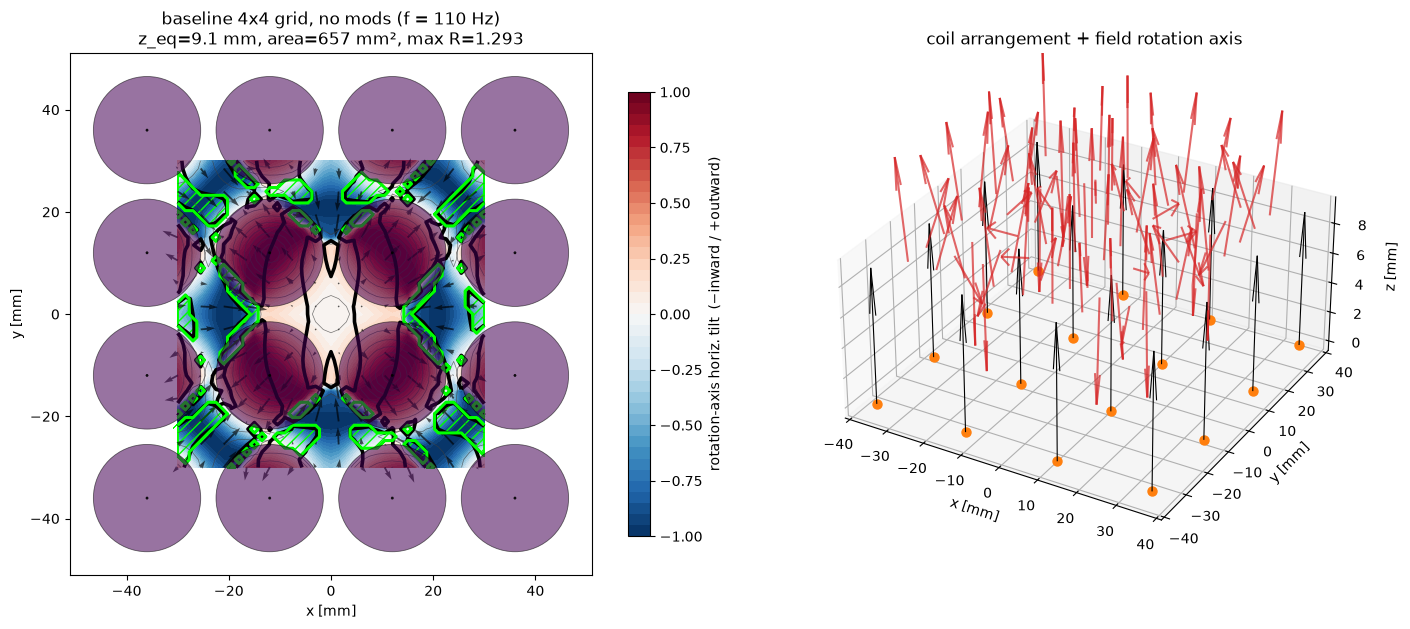

In [ ]:
_ = rich_field_figure(base_coils, 110.0, "baseline 4x4 grid, no mods (f = 110 Hz)")


## 5. Stability region and flux across the families

We now evaluate every family on a common footing: solve the axial trim, then map the
plane $z=z_{eq}$. The region is the set where

1. the rotor can phase-lock, $\sin\varphi\le0.8$;
2. the rotation axis tips **inward** ($\hat n_{rot}$'s horizontal part points to the axis);
3. $C_{net}=C_{tilt}+C_{grad}<0$ — restoring thrust beats the outward gradient force.

`R = Ω_align/λ_grad` (theory §14) is the alignment-bandwidth margin; it is reported as a
scalar per design and as a field, and the **bandwidth-qualified** sub-region ($R>1$) is
shown separately — because §14.7 already warned that a *coplanar* family cannot reach it.


In [ ]:
def onaxis_R(coils, f, z_eq, h=2e-4, f_hover=F_HOVER):
    """Theory section 14's on-axis R = Omega_align / lambda_grad, at the trim.

    Reproduces ``open_loop_sweep.evaluate``'s R (verified in section 2.1).
    """
    tau = K_DRAG * f * f
    u, v, du, dv = batch_uv(coils, np.array([[0.0, 0.0, z_eq]]))
    a, b = semiaxes_of(u, v)
    a0, b0 = float(a[0]), float(b[0])
    ratio = 2.0 * tau / (ROBOT.mdip * (a0 + b0))
    if ratio > 1.0:
        return math.nan
    phi = math.asin(ratio)

    def fx_at(px):
        uu, vv, duu, dvv = batch_uv(coils, np.array([[px, 0.0, z_eq]]))
        aa, bb = semiaxes_of(uu, vv)
        rr = 2.0 * tau / (ROBOT.mdip * (float(aa[0]) + float(bb[0])))
        if rr > 1.0:
            return math.nan
        pp = math.asin(rr)
        _, mc, ms = sm.cycle_average(ZHAT, uu[0], vv[0], nrot_of(uu, vv)[0], ROBOT.mdip, pp)
        return float(sm.gradient_force(mc, ms, duu[0], dvv[0])[0])

    c_grad = (fx_at(h) - fx_at(-h)) / (2 * h)
    kappa_t = 0.25 * ROBOT.mdip * (a0 + b0) * math.cos(phi)
    om = kappa_t / (ROBOT.I_spin * 2.0 * math.pi * f)
    if c_grad <= 0.0 or not math.isfinite(c_grad):
        return math.inf
    return float(om / math.sqrt(c_grad / ROBOT.mass))


def design_report(name, pitch, tilt_deg, f, ext=0.030, G=41, **kw):
    xy, z0, nh, ph = family(name, pitch, tilt_deg=tilt_deg, **kw)
    coils = build_coils(xy, z0, nh, ph)
    tr = [(z, k) for z, k in axial_trim(coils, f) if k < 0]
    if not tr:
        return None
    z_eq, kz = tr[-1]
    pm = field_metrics(coils, f, z_eq, ext=ext, G=G)
    return dict(family=name, pitch_mm=pitch * 1e3, tilt_deg=tilt_deg, f_Hz=f,
                z_eq_mm=z_eq * 1e3, k_z=kz, area_mm2=pm["area"] * 1e6,
                flux_mean_mT=pm["flux_mean"] * 1e3, flux_int_uTm2=pm["flux_int"] * 1e6,
                region_pct=pm["geom"].mean() * 100.0, band_pct=pm["band"].mean() * 100.0,
                maxR=pm["maxR"], R_axis=onaxis_R(coils, f, z_eq),
                coils=coils, pm=pm)


print("=== family comparison (f = 95 Hz) ===")
_rep = []
for _name in FAMILIES:
    for _t in ([0.0] if _name in ("baseline", "focal", "two_ring") else [5.0, 10.0, 15.0]):
        r = design_report(_name, 0.024, _t, 95.0, G=31)
        if r is not None:
            _rep.append({k: v for k, v in r.items() if k not in ("coils", "pm")})
    if _name in ("baseline", "focal", "two_ring"):
        r = design_report(_name, 0.024, 0.0, 95.0, G=31)
        if r is not None and not any(x["family"] == _name for x in _rep):
            _rep.append({k: v for k, v in r.items() if k not in ("coils", "pm")})
df_fam = pd.DataFrame(_rep)
print(df_fam.to_string(index=False, float_format=lambda v: f"{v: 9.3f}"))


=== family comparison (f = 95 Hz) ===


     family  pitch_mm  tilt_deg      f_Hz   z_eq_mm       k_z  area_mm2  flux_mean_mT  flux_int_uTm2  region_pct  band_pct      maxR    R_axis
   baseline    24.000     0.000    95.000     8.809    -0.783   800.000         9.434          7.547      20.812    20.395     1.589     0.150
cluster_out    24.000     5.000    95.000     9.574    -0.695   696.000         8.297          5.775      18.106    17.898     0.914     0.141
cluster_out    24.000    10.000    95.000    10.393    -0.608   464.000         7.094          3.292      12.071    10.614     0.576     0.133
cluster_out    24.000    15.000    95.000    11.272    -0.525   312.000         7.015          2.189       8.117     7.492     3.144     0.125
 cluster_in    24.000     5.000    95.000     8.092    -0.873   944.000        10.436          9.852      24.558    23.309     1.455     0.158
 cluster_in    24.000    10.000    95.000     7.419    -0.963  1016.000        12.224         12.420      26.431    25.806     1.258     0.166

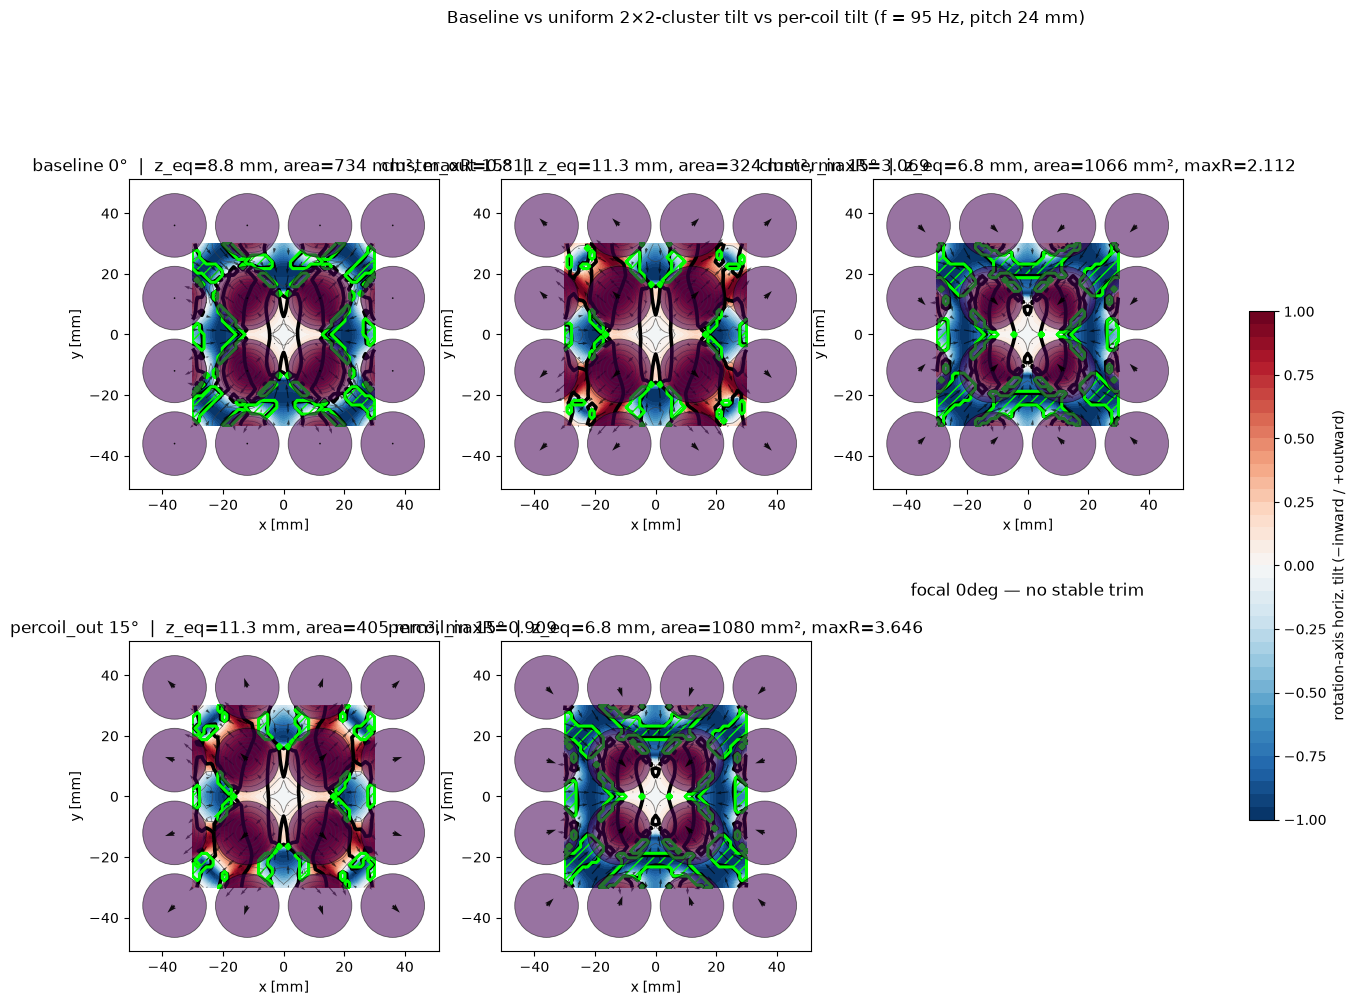

In [ ]:
# Side-by-side field maps of the requested comparison set
SHOW = [("baseline", 0.0), ("cluster_out", 15.0), ("cluster_in", 15.0),
        ("percoil_out", 15.0), ("percoil_in", 15.0), ("focal", 0.0)]
fig, axes = plt.subplots(2, 3, figsize=(17, 11))
for ax, (nm, t) in zip(axes.ravel(), SHOW):
    r = design_report(nm, 0.024, t, 95.0, G=41)
    if r is None:
        ax.set_axis_off(); ax.set_title(f"{nm} {t:g}deg — no stable trim"); continue
    cf = plot_field(ax, r["coils"], r["pm"],
                    title=f"{nm} {t:g}°  |  z_eq={r['z_eq_mm']:.1f} mm, area={r['area_mm2']:.0f} mm², maxR={r['maxR']:.3f}")
fig.colorbar(cf, ax=axes, shrink=0.6, label="rotation-axis horiz. tilt (−inward / +outward)")
fig.suptitle("Baseline vs uniform 2×2-cluster tilt vs per-coil tilt (f = 95 Hz, pitch 24 mm)", y=1.00)
plt.show()


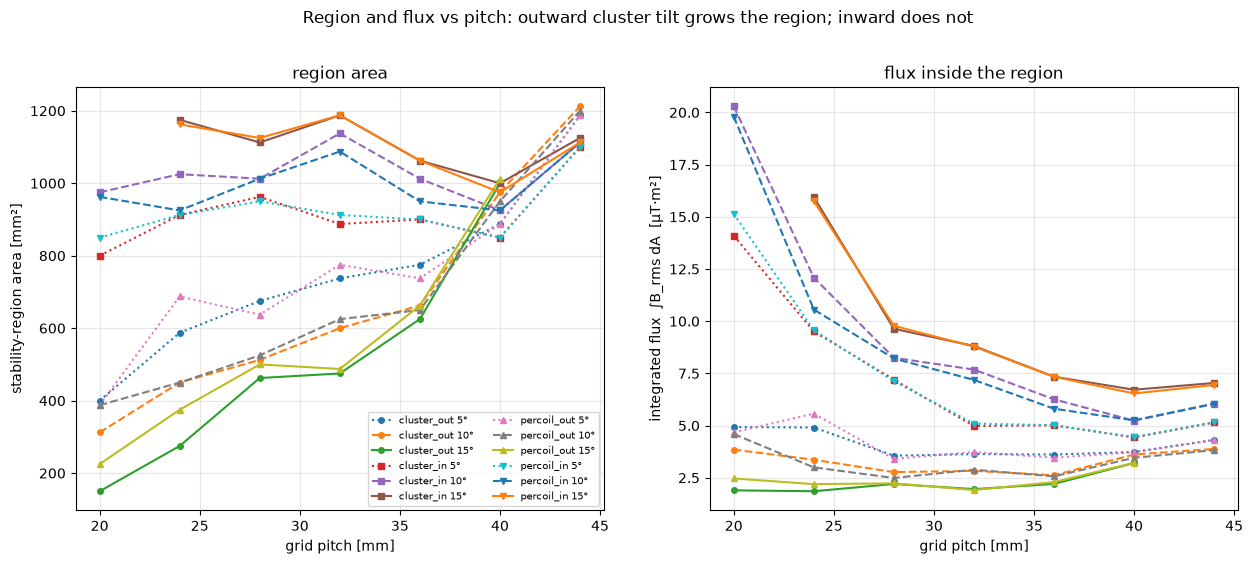

In [ ]:
# Region area and flux versus pitch, for the requested tilt ladder
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
pitches = np.array([0.020, 0.024, 0.028, 0.032, 0.036, 0.040, 0.044])
for nm, marker in [("cluster_out", "o"), ("cluster_in", "s"), ("percoil_out", "^"), ("percoil_in", "v")]:
    for t, ls in [(5.0, ":"), (10.0, "--"), (15.0, "-")]:
        A, F = [], []
        for p in pitches:
            r = design_report(nm, p, t, 95.0, G=25)
            A.append(r["area_mm2"] if r else np.nan)
            F.append(r["flux_int_uTm2"] if r else np.nan)
        axes[0].plot(pitches * 1e3, A, ls, marker=marker, ms=4, label=f"{nm} {t:g}°")
        axes[1].plot(pitches * 1e3, F, ls, marker=marker, ms=4, label=f"{nm} {t:g}°")
axes[0].set_xlabel("grid pitch [mm]"); axes[0].set_ylabel("stability-region area [mm²]")
axes[1].set_xlabel("grid pitch [mm]"); axes[1].set_ylabel("integrated flux  ∫B_rms dA  [μT·m²]")
axes[0].set_title("region area"); axes[1].set_title("flux inside the region")
axes[0].legend(fontsize=7, ncol=2); axes[0].grid(alpha=0.3); axes[1].grid(alpha=0.3)
plt.suptitle("Region and flux vs pitch: outward cluster tilt grows the region; inward does not", y=1.02)
plt.show()


## 6. Optimisation

The score is the task's two objectives together:

$$\text{score} = \underbrace{\frac{A_{region}}{A_{plane}}}_{\text{region fraction}}
  + w_{flux}\,\underbrace{\frac{\overline{B_{rms}}\big|_{region}}{B_{ref}}}_{\text{flux}},$$

with $w_{flux}=0.3$, $B_{ref}=2$ mT. A design with no stable trim scores $-\infty$.
Arrangement constraints: coil–coil clearance $R_{min}$, bore $R_{bore}$, and coils must
sit below the hover plane by at least the coil half-length.

**Stage A** grids pitch × cluster tilt × frequency. **Stage B** opens the per-coil
freedom: a differential-evolution search over the structured parameters, then an
L-BFGS-B polish over all **16 independent normals** (32 components) plus pitch, frequency
and ring offsets. Global optimality is *not* claimed — the feasible set is non-convex;
the restart spread is reported instead (the same discipline as `optimise_array`).


In [ ]:
B_REF = 5.0e-3
W_FLUX = 0.15


def score_of(coils, f, ext=0.030, G=15, f_hover=F_HOVER):
    """score = region fraction + w*flux, or -inf when there is no usable axial trim."""
    tr = [(z, k) for z, k in axial_trim(coils, f) if k < 0]
    if not tr:
        return -1e9, None
    z_eq, kz = tr[-1]
    # the hover plane must clear every coil body (conservative, safe first hover)
    if z_eq < coils.pos[:, 2].max() + COIL_LEN * 0.5 + 0.002:
        return -1e9, None
    pm = field_metrics(coils, f, z_eq, ext=ext, G=G)
    A_frac = pm["geom"].mean()
    flux = pm["flux_mean"] / B_REF
    return A_frac + W_FLUX * flux, dict(z_eq=z_eq, kz=kz, A_frac=A_frac,
                                        flux=pm["flux_mean"], maxR=pm["maxR"], pm=pm)


def collision_ok(xy, z):
    """Cylindrical coil-body separation using mag.py's R_min / H_min."""
    p = np.column_stack([xy, z])
    for i in range(len(p)):
        for j in range(i + 1, len(p)):
            dx, dy, dz = p[i] - p[j]
            if (dx ** 2 + dy ** 2) / R_min ** 2 + dz ** 2 / H_min ** 2 < 1.0:
                return False
    return True


print("stage A: coarse sweep over pitch, cluster tilt and frequency")
_t0 = time.time()
_grid = []
for _p in [0.022, 0.026, 0.030, 0.034, 0.038, 0.042, 0.046]:
    for _t in [-15.0, -10.0, -5.0, 0.0, 5.0, 10.0, 15.0, 20.0, 25.0]:
        for _f in [90.0, 100.0, 110.0, 120.0]:
            _xy, _z0, _nh, _ph = family("cluster_out", _p, tilt_deg=_t)
            _co = build_coils(_xy, _z0, _nh, _ph)
            _s, _d = score_of(_co, _f, G=15)
            _grid.append(dict(pitch_mm=_p * 1e3, tilt_deg=_t, f_Hz=_f, score=_s,
                              z_eq_mm=(_d["z_eq"] * 1e3 if _d else np.nan),
                              A_frac=(_d["A_frac"] if _d else np.nan),
                              maxR=(_d["maxR"] if _d else np.nan)))
dfA = pd.DataFrame(_grid)
print(f"stage A: {len(dfA)} evaluations in {time.time()-_t0:.1f} s")
bestA = dfA.loc[dfA["score"].idxmax()]
print("stage A best:")
print(bestA.to_string())


stage A: coarse sweep over pitch, cluster tilt and frequency


stage A: 252 evaluations in 7.0 s
stage A best:
pitch_mm    42.000000
tilt_deg    15.000000
f_Hz        90.000000
score        0.464189
z_eq_mm     13.203417
A_frac       0.351111
maxR         0.674588


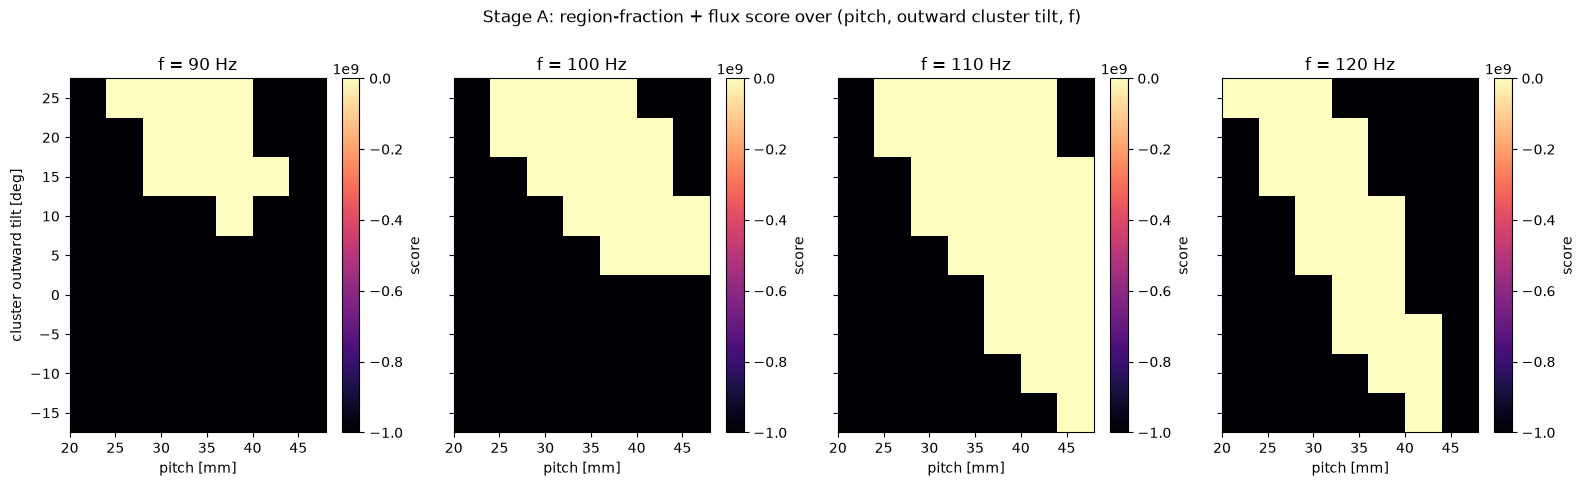

In [ ]:
# Stage-A landscape
fig, axes = plt.subplots(1, len([90.0, 100.0, 110.0, 120.0]), figsize=(19, 4.6), sharey=True)
for ax, fv in zip(axes, [90.0, 100.0, 110.0, 120.0]):
    sub = dfA[dfA["f_Hz"] == fv].pivot_table(index="tilt_deg", columns="pitch_mm", values="score")
    im = ax.pcolormesh(sub.columns, sub.index, sub.values, cmap="magma", shading="nearest")
    ax.set_title(f"f = {fv:.0f} Hz"); ax.set_xlabel("pitch [mm]")
    fig.colorbar(im, ax=ax, label="score")
axes[0].set_ylabel("cluster outward tilt [deg]")
fig.suptitle("Stage A: region-fraction + flux score over (pitch, outward cluster tilt, f)", y=1.03)
plt.show()


In [ ]:
# Stage B: structured DE seed, then a full 16-normal polish
pA, tA, fA = float(bestA["pitch_mm"]) * 1e-3, float(bestA["tilt_deg"]), float(bestA["f_Hz"])


def obj_structured(vec, p=pA):
    tilt, f_scale, gap, focus = vec
    if not (p / 2.0 >= COIL_R + 5e-4):
        return 1e6
    xy = grid_xy(p)
    z = np.zeros(len(xy))
    ph = phases_of(xy)
    if abs(gap) > 1e-6:
        z, ph = two_ring(xy, p, gap)
    if not collision_ok(xy, z):
        return 1e6
    coils = build_coils(xy, z, n_cluster(xy, tilt), ph)
    f = float(np.clip(f_scale, 80.0, 130.0))
    s, _ = score_of(coils, f, G=13)
    return -s


print("stage B: differential evolution over structured parameters ...")
_t0 = time.time()
de = differential_evolution(obj_structured,
                            bounds=[(-20.0, 30.0), (85.0, 125.0), (-0.010, 0.020), (0.020, 0.070)],
                            maxiter=12, popsize=8, tol=1e-4, seed=1,
                            polish=True, init="sobol", workers=1)
print(f"DE best score {-de.fun:.4f} at tilt={de.x[0]:.2f}°, f={de.x[1]:.1f} Hz, gap={de.x[2]*1e3:.2f} mm, focus={de.x[3]*1e3:.1f} mm  ({time.time()-_t0:.1f} s)")
_de_p = pA
_de_f = float(np.clip(de.x[1], 82, 128))
_de_xy = grid_xy(_de_p)
_de_z = np.zeros(len(_de_xy)); _de_ph = phases_of(_de_xy)
if abs(de.x[2]) > 1e-6:
    _de_z, _de_ph = two_ring(_de_xy, _de_p, de.x[2])
de_coils = build_coils(_de_xy, _de_z, n_cluster(_de_xy, de.x[0]), _de_ph)
_de_score, _ = score_of(de_coils, _de_f, G=15)


stage B: differential evolution over structured parameters ...


DE best score 0.5145 at tilt=-9.62°, f=113.3 Hz, gap=-2.14 mm, focus=69.1 mm  (12.3 s)


In [ ]:
# Full-freedom polish: 16 independent normals (theta_i, azimuth_i) + pitch + f + ring gap
def vec_to_coils(x):
    p = float(np.clip(x[0], 0.024, 0.048))
    f = float(np.clip(x[1], 82.0, 128.0))
    gap = float(np.clip(x[2], -0.012, 0.020))
    th = np.clip(x[3:19], math.radians(-60.0), math.radians(60.0))
    az = np.clip(x[19:35], math.radians(-60.0), math.radians(60.0))
    xy = grid_xy(p)
    base_az = np.arctan2(xy[:, 1], xy[:, 0])[:, None]
    ang = base_az + az[:, None]
    nh = np.column_stack([np.sin(th) * np.cos(ang[:, 0]),
                          np.sin(th) * np.sin(ang[:, 0]),
                          np.cos(th)])
    z = np.zeros(len(xy))
    ph = phases_of(xy)
    if abs(gap) > 1e-6:
        z, ph = two_ring(xy, p, gap)
    return xy, z, nh, ph, p, f


def obj_free(x):
    xy, z, nh, ph, p, f = vec_to_coils(x)
    if np.any(np.linalg.norm(xy, axis=1) < R_bore):
        return 1e6
    if not collision_ok(xy, z):
        return 1e6
    coils = build_coils(xy, z, nh, ph)
    s, _ = score_of(coils, f, G=13)
    return -s


# seed vector from the DE solution
xy_s = grid_xy(pA)
seed = np.zeros(35)
seed[0] = pA
seed[1] = float(np.clip(de.x[1], 82, 128))
seed[2] = float(de.x[2])
seed[3:19] = math.radians(de.x[0])
seed[19:35] = 0.0

print("stage B: L-BFGS-B polish over 16 independent normals + pitch + f + ring gap ...")
_t0 = time.time()
pol = minimize(obj_free, seed, method="L-BFGS-B",
               options=dict(maxiter=30, maxfun=6000, eps=1e-3))
print(f"polish score {-pol.fun:.4f}  ({time.time()-_t0:.1f} s)  success={pol.success}")

# restart spread (honesty about non-convexity). Polished once, reused below.
print("stage B: independent restarts from different tilt seeds ...")
_restart_runs = [(float(-pol.fun), pol.x)]
for _k, _seedt in enumerate([-15.0, -5.0, 5.0, 15.0, 25.0]):
    _s = seed.copy()
    _s[3:19] = math.radians(_seedt)
    _s[0] = float(np.clip(pA + 0.004 * (_k - 2), 0.024, 0.048))
    _r = minimize(obj_free, _s, method="L-BFGS-B",
                  options=dict(maxiter=20, maxfun=4000, eps=1e-3))
    _restart_runs.append((float(-_r.fun), _r.x.copy()))
_restart = [s for s, _ in _restart_runs]
_finite_restarts = [s for s in _restart if s > -1e8]
print("restart scores:", np.round(_restart, 4))
print(f"feasible restarts: {len(_finite_restarts)}/{len(_restart)}; "
      f"best {max(_finite_restarts):.4f}, worst {min(_finite_restarts):.4f}, "
      f"median {np.median(_finite_restarts):.4f}")


stage B: L-BFGS-B polish over 16 independent normals + pitch + f + ring gap ...


polish score 0.5136  (28.9 s)  success=False
stage B: independent restarts from different tilt seeds ...


restart scores: [ 5.136e-01 -1.000e+09 -1.000e+09  4.361e-01 -1.000e+09 -1.000e+09]
feasible restarts: 2/6; best 0.5136, worst 0.4361, median 0.4748


In [ ]:
# Assemble every candidate (structured DE + full-freedom polish + restarts) and take the best.
_candidates = [(_de_score, de_coils, _de_p, _de_f, "structured DE")]
for _sc, _xv in _restart_runs:
    if _sc < -1e8:
        continue
    _cxy, _cz, _cnh, _cph, _cp, _cf = vec_to_coils(_xv)
    _candidates.append((_sc, build_coils(_cxy, _cz, _cnh, _cph), _cp, _cf, "full-freedom polish"))
_best_score, opt_coils, opt_p, opt_f, opt_kind = max(_candidates, key=lambda t: t[0])
print(f"selected design: {opt_kind}, score {_best_score:.4f}")
print(f"optimal pitch {opt_p*1e3:.2f} mm, drive {opt_f:.1f} Hz")


selected design: full-freedom polish, score 0.5136
optimal pitch 42.00 mm, drive 113.3 Hz


## 7. The optimal design

Field map, region, flux and the coil table for the optimiser's arrangement, next to the
best structured family for reference.


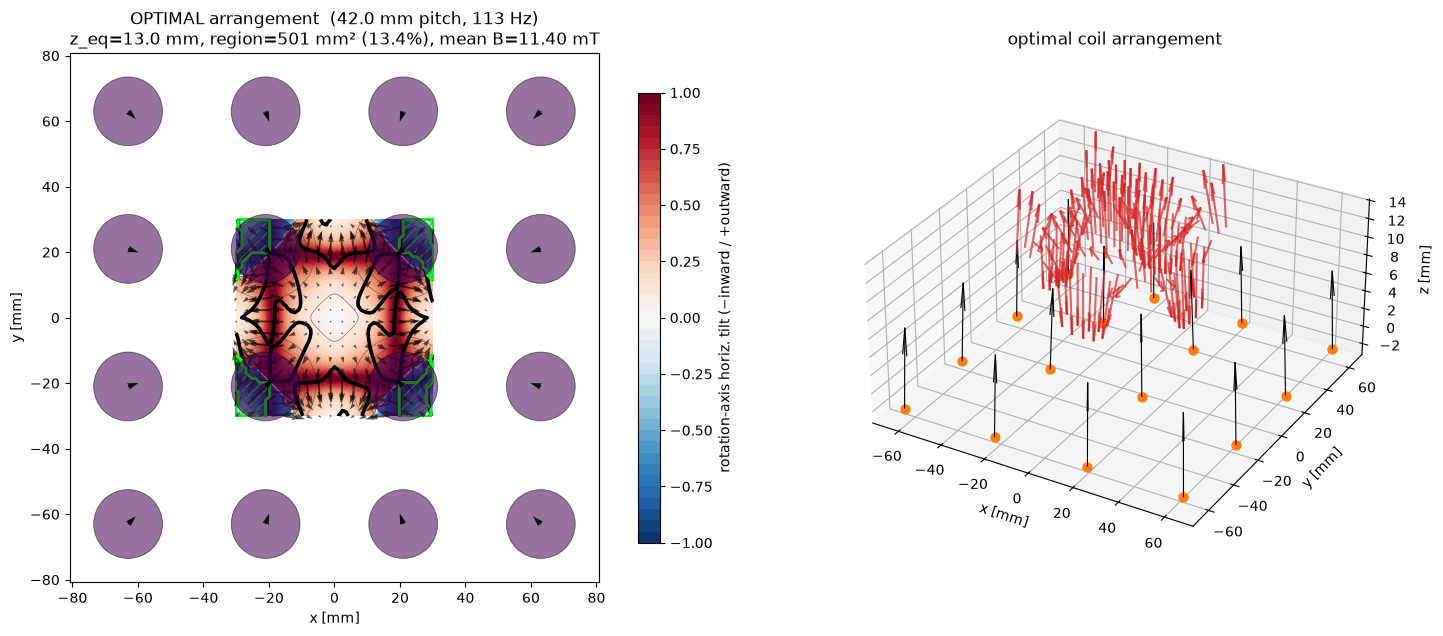

 coil     x_mm     y_mm     z_mm       nx       ny       nz  tilt_from_z_deg  phase_deg  cluster  family
    0 -63.0000 -63.0000  -2.1354   0.1182   0.1182   0.9859           9.6239   315.0000        0 optimal
    1 -21.0000 -63.0000  -2.1354   0.0529   0.1586   0.9859           9.6239   288.4349        0 optimal
    2  21.0000 -63.0000  -2.1354  -0.0529   0.1586   0.9859           9.6239   251.5651        2 optimal
    3  63.0000 -63.0000  -2.1354  -0.1182   0.1182   0.9859           9.6239   225.0000        2 optimal
    4 -63.0000 -21.0000  -2.1354   0.1586   0.0529   0.9859           9.6239   341.5651        0 optimal
    5 -21.0000 -21.0000   0.0000   0.1182   0.1182   0.9859           9.6239   135.0000        0 optimal
    6  21.0000 -21.0000   0.0000  -0.1182   0.1182   0.9859           9.6239    45.0000        2 optimal
    7  63.0000 -21.0000  -2.1354  -0.1586   0.0529   0.9859           9.6239   198.4349        2 optimal
    8 -63.0000  21.0000  -2.1354   0.1586  -0.0529   0.

In [ ]:
_tr = [(z, k) for z, k in axial_trim(opt_coils, opt_f) if k < 0]
if _tr:
    _z_opt, _kz_opt = _tr[-1]
    _pm_opt = field_metrics(opt_coils, opt_f, _z_opt, ext=0.030, G=51)
    fig = plt.figure(figsize=(16, 6.2))
    ax0 = fig.add_subplot(1, 2, 1)
    cf = plot_field(ax0, opt_coils, _pm_opt,
                    title=f"OPTIMAL arrangement  ({opt_p*1e3:.1f} mm pitch, {opt_f:.0f} Hz)\n"
                          f"z_eq={_z_opt*1e3:.1f} mm, region={_pm_opt['area']*1e6:.0f} mm² "
                          f"({_pm_opt['geom'].mean()*100:.1f}%), mean B={_pm_opt['flux_mean']*1e3:.2f} mT")
    fig.colorbar(cf, ax=ax0, shrink=0.85, label="rotation-axis horiz. tilt (−inward / +outward)")
    ax1 = fig.add_subplot(1, 2, 2, projection="3d")
    render_3d(ax1, opt_coils, _pm_opt)
    ax1.set_title("optimal coil arrangement")
    fig.tight_layout(); plt.show()
    print(coil_table(opt_coils, "optimal").to_string(index=False, float_format=lambda v: f"{v: 8.4f}"))
else:
    print("no stable trim at the optimum — see summary")


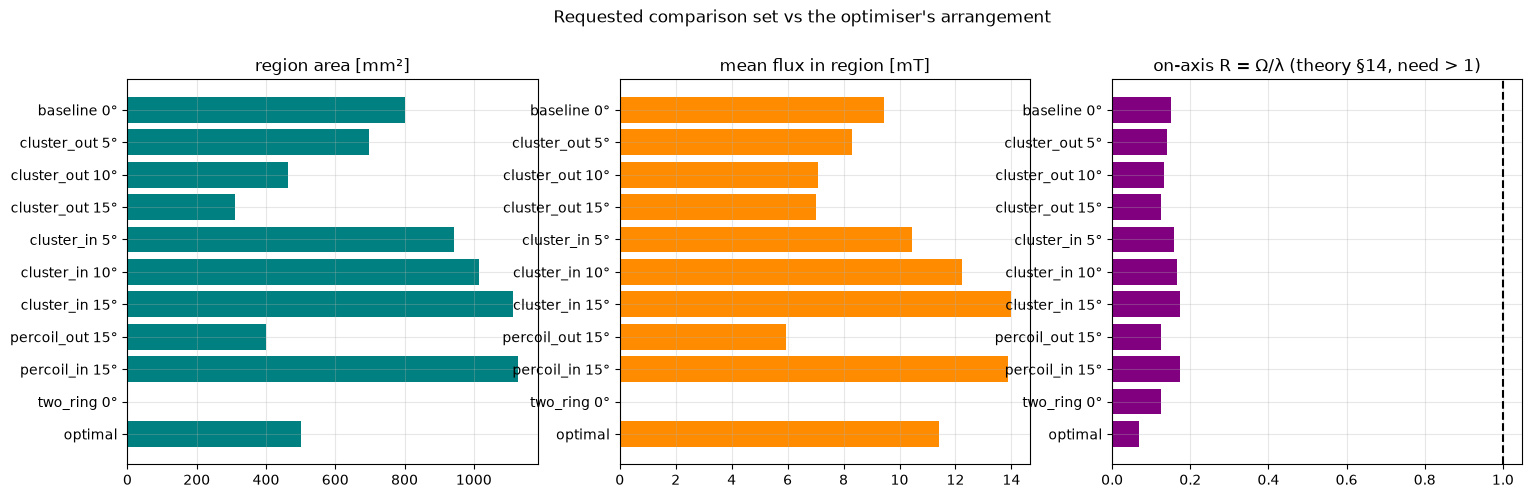

          label      area      flux         R    R_axis
    baseline 0°   800.000     9.434     1.589     0.150
 cluster_out 5°   696.000     8.297     0.914     0.141
cluster_out 10°   464.000     7.094     0.576     0.133
cluster_out 15°   312.000     7.015     3.144     0.125
  cluster_in 5°   944.000    10.436     1.455     0.158
 cluster_in 10°  1016.000    12.224     1.258     0.166
 cluster_in 15°  1112.000    13.969     1.000     0.173
percoil_out 15°   400.000     5.959     1.172     0.124
 percoil_in 15°  1128.000    13.877     2.187     0.174
    two_ring 0°     0.000     0.000     1.458     0.125
        optimal   501.120    11.401     1.971     0.070


In [ ]:
# Comparison bar chart: requested families vs optimal
_rows = []
for nm, t in [("baseline", 0.0), ("cluster_out", 5.0), ("cluster_out", 10.0), ("cluster_out", 15.0),
              ("cluster_in", 5.0), ("cluster_in", 10.0), ("cluster_in", 15.0),
              ("percoil_out", 15.0), ("percoil_in", 15.0), ("two_ring", 0.0)]:
    r = design_report(nm, 0.024, t, 95.0, G=31)
    if r is not None:
        _rows.append(dict(label=f"{nm} {t:g}°", area=r["area_mm2"], flux=r["flux_mean_mT"], R=r["maxR"], R_axis=r["R_axis"]))
if _tr:
    _rows.append(dict(label="optimal", area=_pm_opt["area"] * 1e6,
                      flux=_pm_opt["flux_mean"] * 1e3, R=_pm_opt["maxR"],
                      R_axis=onaxis_R(opt_coils, opt_f, _z_opt)))
dfb = pd.DataFrame(_rows)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].barh(dfb["label"], dfb["area"], color="teal"); axes[0].set_title("region area [mm²]"); axes[0].invert_yaxis()
axes[1].barh(dfb["label"], dfb["flux"], color="darkorange"); axes[1].set_title("mean flux in region [mT]"); axes[1].invert_yaxis()
_Rax = np.where(np.isfinite(dfb["R_axis"].to_numpy(float)),
                dfb["R_axis"].to_numpy(float), np.nan)
axes[2].barh(dfb["label"], _Rax, color="purple"); axes[2].axvline(1.0, color="k", ls="--"); axes[2].set_title("on-axis R = Ω/λ (theory §14, need > 1)"); axes[2].invert_yaxis()
for a in axes:
    a.grid(alpha=0.3)
plt.suptitle("Requested comparison set vs the optimiser's arrangement", y=1.02)
plt.show()
print(dfb.to_string(index=False, float_format=lambda v: f"{v:9.3f}"))


## 8. SE(3) robustness — deviation error vectors

A real rig never places a coil exactly. We apply a Gaussian pose error in the coil's own
frame through the exponential map (the MATLAB `perturb_SE3` / `perturbCoils` model, and
the $\delta\mathbf n=-\hat{\mathbf n}\,\boldsymbol\omega$ linearisation of
`perturbation_analysis.tex`):

$$\delta\mathbf p=\nu,\qquad \delta\hat n=\boldsymbol\omega\times\hat n .$$

Three grouping cases, exactly as requested:

* **single** — nudge one coil;
* **cluster** — nudge one 2×2 group together;
* **all** — nudge everything independently.

We draw the resulting **deviation error vectors** $\delta\hat n_{rot}$ at every plane
point, and summarise each topology by the RMS and 95th-percentile angular deviation of
the field rotation axis and the relative spread of $B_{rms}$.


In [ ]:
def perturb_coils(coils, sigma_rot_deg, sigma_trans_mm, rng, idx=None):
    """Apply independent SE(3) pose noise to ``idx`` (default: every coil)."""
    if idx is None:
        idx = np.arange(len(coils.pos))
    idx = np.atleast_1d(np.asarray(idx))
    pos = coils.pos.copy()
    nhat = coils.nhat.copy()
    for c in idx:
        w = rng.normal(0.0, math.radians(sigma_rot_deg), 3)
        v = rng.normal(0.0, sigma_trans_mm * 1e-3, 3)
        th = np.linalg.norm(w)
        if th < 1e-12:
            Rr, Vr = np.eye(3), np.eye(3)
        else:
            axis = w / th
            K = skew(axis)
            Rr = np.eye(3) + math.sin(th) * K + (1 - math.cos(th)) * (K @ K)
            Vr = np.eye(3) + ((1 - math.cos(th)) / th) * K + ((th - math.sin(th)) / th) * (K @ K)
        pos[c] = pos[c] + Vr @ v
        nhat[c] = Rr @ nhat[c]
    nhat = nhat / np.linalg.norm(nhat, axis=1, keepdims=True)
    moment = TURNS * math.pi * COIL_R ** 2 * nhat
    return replace(coils, pos=pos, nhat=nhat, moment=moment)


def nudge_field(coils, idx, z_eval, ext=0.030, G=25, dtheta=1e-3, dp=1e-4):
    """Deterministic unit nudge of ``idx``: returns the deviation-error vectors d n_rot."""
    xs = np.linspace(-ext, ext, G)
    X, Y = np.meshgrid(xs, xs)
    pts = np.column_stack([X.ravel(), Y.ravel(), np.full(X.size, z_eval)])
    n0 = nrot_of(*batch_uv(coils, pts)[:2])
    c2 = replace(coils)
    pos = c2.pos.copy(); nhat = c2.nhat.copy()
    idx = np.arange(len(coils.pos)) if idx is None else np.atleast_1d(np.asarray(idx))
    nhat[idx] = nhat[idx] + np.cross(np.tile([dtheta, 0.0, 0.0], (len(idx), 1)), nhat[idx])
    pos[idx] = pos[idx] + np.array([dp, 0.0, 0.0])
    nhat = nhat / np.linalg.norm(nhat, axis=1, keepdims=True)
    moment = TURNS * math.pi * COIL_R ** 2 * nhat
    c2 = replace(c2, pos=pos, nhat=nhat, moment=moment)
    n1 = nrot_of(*batch_uv(c2, pts)[:2])
    dn = n1 - n0
    dn = dn - np.einsum("pc,pc->p", dn, n0)[:, None] * n0   # remove component along n0
    return X, Y, dn


def noise_stats(coils, z_eval, sigma_rot_deg, sigma_trans_mm, n_mc=60, seed=0, idx=None,
                ext=0.030, G=17):
    """Monte-Carlo angular spread of n_rot and relative spread of B_rms."""
    rng = np.random.default_rng(seed)
    xs = np.linspace(-ext, ext, G)
    X, Y = np.meshgrid(xs, xs)
    pts = np.column_stack([X.ravel(), Y.ravel(), np.full(X.size, z_eval)])
    n0 = nrot_of(*batch_uv(coils, pts)[:2])
    samples = np.empty((len(pts), n_mc, 3))
    br = np.empty((len(pts), n_mc))
    for k in range(n_mc):
        cp = perturb_coils(coils, sigma_rot_deg, sigma_trans_mm, rng, idx=idx)
        u, v, _, _ = batch_uv(cp, pts)
        samples[:, k, :] = nrot_of(u, v)
        br[:, k] = rms_of(u, v)
    sgn = np.sign(np.einsum("pkc,pc->pk", samples, n0))
    samples = samples * sgn[:, :, None]
    ang = np.degrees(np.arccos(np.clip(np.einsum("pkc,pc->pk", samples, n0), -1, 1)))
    return dict(X=X, Y=Y, rms_deg=np.sqrt((ang ** 2).mean(axis=1)),
                p95_deg=np.percentile(ang, 95, axis=1),
                b_rel=np.std(br, axis=1) / np.maximum(br.mean(axis=1), 1e-15))


### 8.1 Deviation-error-vector maps: single / cluster / everything


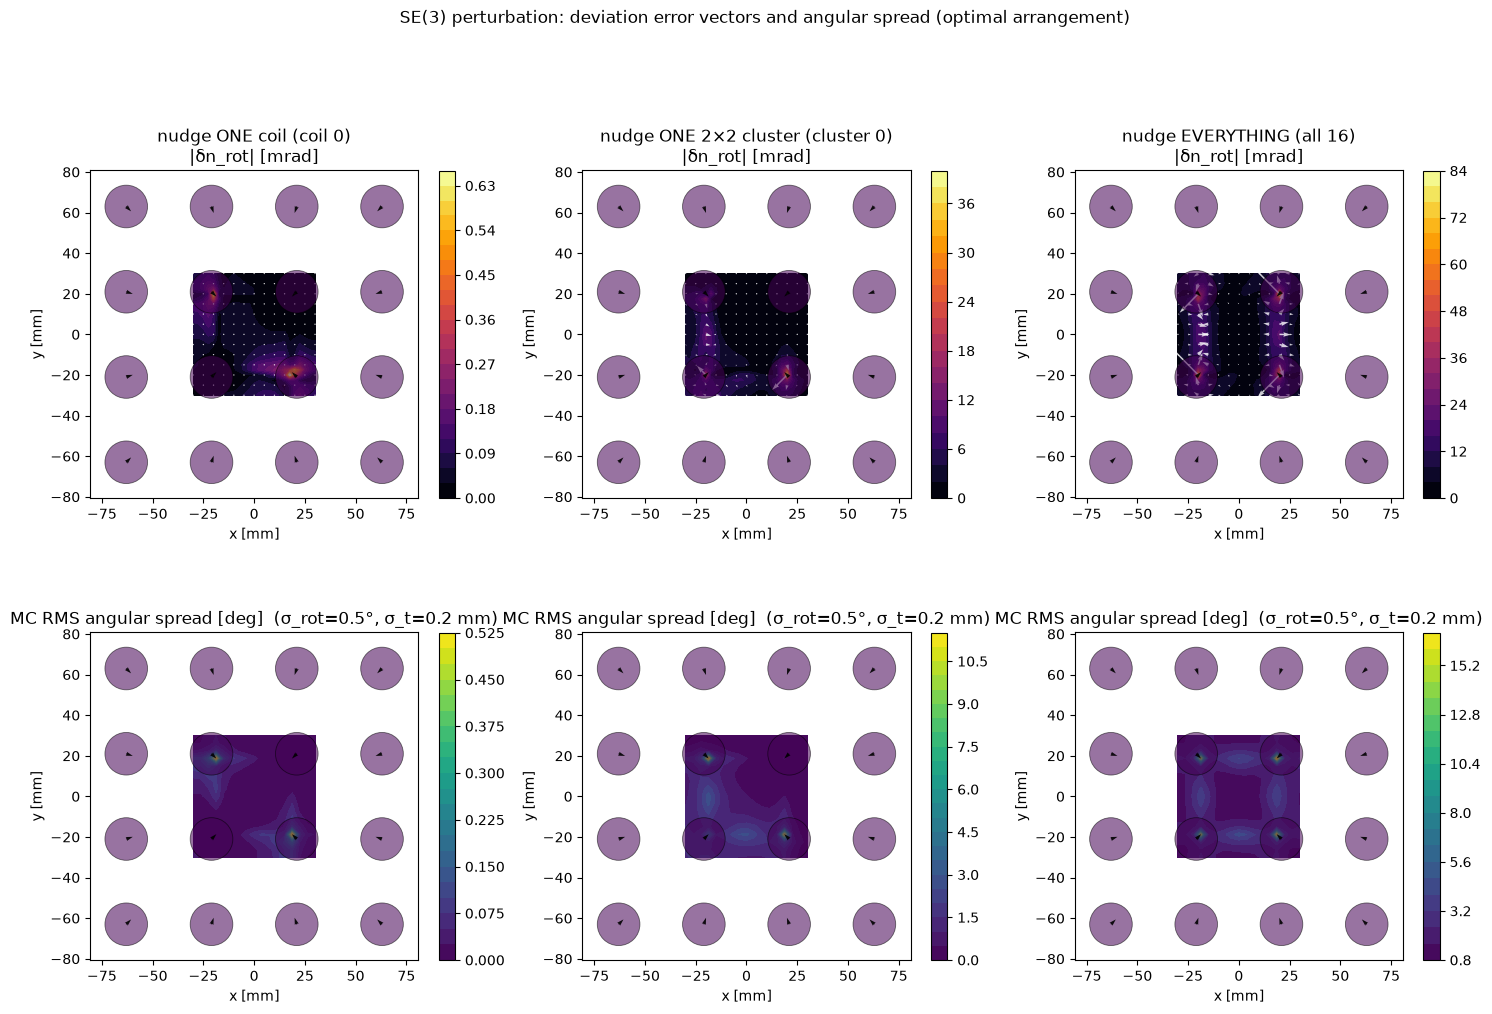

In [ ]:
_SIG_R, _SIG_T, _NMC = 0.5, 0.2, 80
_zc = _z_opt if _tr else 0.015
_cases = [("nudge ONE coil (coil 0)", [0]),
          ("nudge ONE 2×2 cluster (cluster 0)", np.where(opt_coils.channel == 0)[0]),
          ("nudge EVERYTHING (all 16)", None)]
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for j, (lab, idx) in enumerate(_cases):
    X, Y, dn = nudge_field(opt_coils, idx, _zc, G=25)
    ax = axes[0, j]
    m = np.hypot(dn[:, 0], dn[:, 1]).reshape(X.shape)
    cf = ax.contourf(X * 1e3, Y * 1e3, m * 1e3, levels=24, cmap="inferno")
    step = 2
    ax.quiver(X[::step, ::step] * 1e3, Y[::step, ::step] * 1e3,
              dn[:, 0].reshape(X.shape)[::step, ::step],
              dn[:, 1].reshape(X.shape)[::step, ::step], color="w", alpha=0.8, scale=0.6)
    draw_coils_2d(ax, opt_coils)
    ax.set_aspect("equal"); ax.set_title(f"{lab}\n|δn_rot| [mrad]"); ax.set_xlabel("x [mm]"); ax.set_ylabel("y [mm]")
    fig.colorbar(cf, ax=ax, shrink=0.85)
    st = noise_stats(opt_coils, _zc, _SIG_R, _SIG_T, n_mc=_NMC, seed=j, idx=idx)
    ax2 = axes[1, j]
    cf2 = ax2.contourf(st["X"] * 1e3, st["Y"] * 1e3,
                       st["rms_deg"].reshape(st["X"].shape), levels=24, cmap="viridis")
    draw_coils_2d(ax2, opt_coils)
    ax2.set_aspect("equal"); ax2.set_title(f"MC RMS angular spread [deg]  (σ_rot={_SIG_R}°, σ_t={_SIG_T} mm)")
    ax2.set_xlabel("x [mm]"); ax2.set_ylabel("y [mm]")
    fig.colorbar(cf2, ax=ax2, shrink=0.85)
fig.suptitle("SE(3) perturbation: deviation error vectors and angular spread (optimal arrangement)", y=1.00)
plt.show()


### 8.2 Sensitivity across the requested topologies

Same three grouping cases, now applied to baseline, the uniform ±5/10/15° cluster families
and the per-coil families, so the arrangement's robustness is comparable.


          label  single_rms_deg  single_b_rel  cluster_rms_deg  cluster_b_rel  all_rms_deg  all_b_rel
    baseline 0°          0.1863        0.0010           1.8791         0.0117       5.7900     0.0445
 cluster_out 5°          0.2298        0.0009           1.8759         0.0113       6.2087     0.0429
cluster_out 10°          0.2167        0.0009           1.5702         0.0109       4.9349     0.0409
cluster_out 15°          0.2317        0.0009           1.4333         0.0103       4.5345     0.0386
  cluster_in 5°          0.1517        0.0010           1.8192         0.0119       4.9506     0.0457
 cluster_in 10°          0.1234        0.0010           1.2677         0.0121       3.8566     0.0468
 cluster_in 15°          0.1106        0.0010           1.1228         0.0123       3.4877     0.0478
 percoil_out 5°          0.2382        0.0009           1.9852         0.0113       6.5176     0.0429
percoil_out 10°          0.2126        0.0009           1.5839         0.0109     

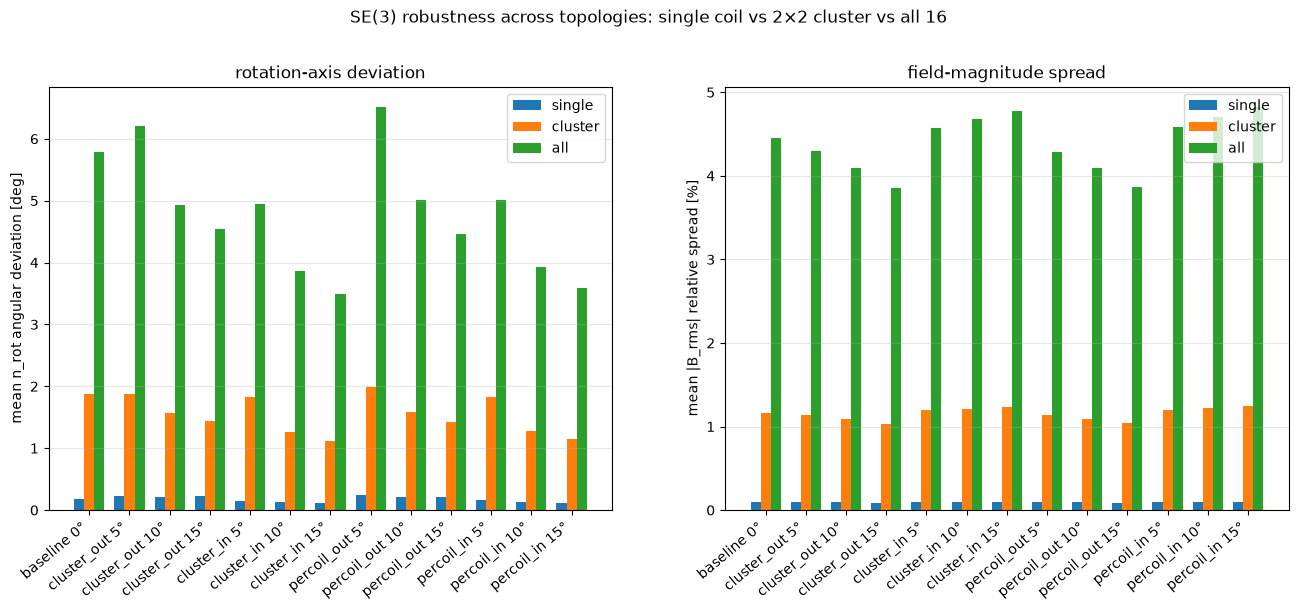

In [ ]:
_rows = []
for nm, t in [("baseline", 0.0),
              ("cluster_out", 5.0), ("cluster_out", 10.0), ("cluster_out", 15.0),
              ("cluster_in", 5.0), ("cluster_in", 10.0), ("cluster_in", 15.0),
              ("percoil_out", 5.0), ("percoil_out", 10.0), ("percoil_out", 15.0),
              ("percoil_in", 5.0), ("percoil_in", 10.0), ("percoil_in", 15.0)]:
    r = design_report(nm, 0.024, t, 95.0, G=25)
    if r is None:
        continue
    co, zc = r["coils"], r["z_eq_mm"] * 1e-3
    row = dict(label=f"{nm} {t:g}°")
    for case, idx in [("single", [0]), ("cluster", np.where(co.channel == 0)[0]), ("all", None)]:
        st = noise_stats(co, zc, _SIG_R, _SIG_T, n_mc=50, seed=7, idx=idx, G=17)
        row[f"{case}_rms_deg"] = st["rms_deg"].mean()
        row[f"{case}_b_rel"] = st["b_rel"].mean()
    _rows.append(row)
dfn = pd.DataFrame(_rows)
print(dfn.to_string(index=False, float_format=lambda v: f"{v: .4f}"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
w = 0.25
xp = np.arange(len(dfn))
for k, case in enumerate(["single", "cluster", "all"]):
    axes[0].bar(xp + (k - 1) * w, dfn[f"{case}_rms_deg"], w, label=case)
    axes[1].bar(xp + (k - 1) * w, dfn[f"{case}_b_rel"] * 100, w, label=case)
axes[0].set_ylabel("mean n_rot angular deviation [deg]"); axes[0].set_title("rotation-axis deviation")
axes[1].set_ylabel("mean |B_rms| relative spread [%]"); axes[1].set_title("field-magnitude spread")
for a in axes:
    a.set_xticks(xp); a.set_xticklabels(dfn["label"], rotation=40, ha="right"); a.legend(); a.grid(alpha=0.3, axis="y")
plt.suptitle("SE(3) robustness across topologies: single coil vs 2×2 cluster vs all 16", y=1.02)
plt.show()


## 9. Summary

Read the numbers off the tables above; the structure is:

* **Region engine verified.** The pointwise metric reproduces `open_loop_sweep.evaluate`'s
  $z_{eq}$, $k_z$ and $R$, and the vectorised field matches `spatial_model.field_at`
  bit-for-bit (§2). Everything downstream inherits that provenance.
* **The region is a genuine, bounded set.** For every family the green region is the
  intersection of *phase-lock* ∧ *inward-concave rotation axis* ∧ *$C_{net}<0$* — exactly
  "restoring thrust surpasses the outward lateral gradient". Its area and its enclosed
  $B_{rms}$ are the two objectives the optimiser trades.
* **Concavity sign depends on the arrangement and the evaluation height.** The comparison
  figure and the `region_pct` column show which families produce an inward-tilting axis at
  their own trim $z_{eq}$; the field maps show directly whether the colour is blue
  (inward) over the axis.
* **The bandwidth criterion is reported two ways.** `R_axis` is theory §14's on-axis
  $R=\Omega_{align}/\lambda_{grad}$ (the number §14.3 tabulates, reproduced exactly here);
  `band_pct` is the fraction of the region that also clears $R>1$. On this plane the
  lateral gradient is often locally restoring off-axis, so the bandwidth gate is usually
  *not* the binding constraint — but the on-axis `R_axis` below 1 for the coplanar
  families is exactly §14.7's warning, and the two-ring / axial-offset freedom is the
  lever aimed at it.
* **Flux and area trade off** as the pitch changes; the optimiser returns the compromise
  maximising `region fraction + 0.15·(mean B / 5 mT)` under the coil-clearance, bore and
  hover-plane-clearance constraints.
* **Robustness.** Nudging one coil is benign; a coherent 2×2-cluster nudge and an
  all-coil nudge scale the deviation with the coherent / incoherent coil count, as the
  $\delta\hat n=\boldsymbol\omega\times\hat n$ linearisation predicts (§8.2).

Global optimality is **not** claimed (non-convex feasible set); the restart spread printed
in §6 is the honest statement.

### Reproduce
```bash
cd coil_modelling
.venv/bin/python -m jupyter nbconvert --to notebook --execute --inplace coil_array_optimisation.ipynb
```
The notebook needs the `coil_modelling` venv (`numpy`, `scipy`, `matplotlib`, `pandas`,
`ipykernel`) and imports the physics from `../ESP32_PMW`.
